### ***Data Cleaning and Preparation For Time-Series Analysis***

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_excel('/content/drive/MyDrive/ChitwanDataset.xls', engine='xlrd')

In [ ]:
# Code cell to avoid 'Groundhog day'

import os

# Define the path to your cleaned file
cleaned_file_path = '/content/drive/MyDrive/chitwan_timeseries.csv'

if os.path.exists(cleaned_file_path):
   print("Cleaned dataset found. Loading from Drive...")
   df_timeseries = pd.read_csv(cleaned_file_path)
else:
   print("Cleaned dataset not found.")

# Final check of the data
print(f"Dataset Ready: {df_timeseries.shape[0]} records available.")

Cleaned dataset found. Loading from Drive...
Dataset Ready: 1986 records available.


In [ ]:
#Dropping unnecessary columns
df_timeseries = df.dropna(subset=['Year', 'Month', 'Day'])

df_timeseries = df_timeseries[['Year', 'Month', 'Day', 'LUNAR_DAY',
                                'PROBLEM_ANIMAL', 'CONFLICT_TYPE',
                                'LOSS_INCURRED']]

In [ ]:
# Verification
df_timeseries.head(20)

,Year,Month,Day,LUNAR_DAY,PROBLEM_ANIMAL,CONFLICT_TYPE,LOSS_INCURRED
1124,2002.0,12.0,1.0,27.0,Tiger,Livestock depredation,Goat/sheep
1125,2003.0,6.0,13.0,14.0,Leopard,Livestock depredation,Goat/sheep
1126,2003.0,6.0,15.0,16.0,Tiger,Livestock depredation,Goat/sheep
1127,2003.0,4.0,19.0,18.0,Tiger,Livestock depredation,Cow/Ox
1128,2003.0,7.0,13.0,14.0,Leopard,Livestock depredation,Goat/sheep
1129,2003.0,6.0,26.0,27.0,Leopard,Livestock depredation,Goat/sheep
1130,2003.0,6.0,22.0,23.0,Leopard,Livestock depredation,Goat/sheep
1131,2003.0,6.0,21.0,22.0,Leopard,Livestock depredation,Goat/sheep
1132,2003.0,6.0,20.0,21.0,Leopard,Livestock depredation,Goat/sheep
1133,2003.0,6.0,16.0,17.0,Leopard,Livestock depredation,Goat/sheep


In [ ]:
# Standardize categorical columns
df_timeseries['PROBLEM_ANIMAL'] = df_timeseries['PROBLEM_ANIMAL'].str.strip().str.title()
df_timeseries['CONFLICT_TYPE'] = df_timeseries['CONFLICT_TYPE'].str.strip().str.title()

In [ ]:
# Remove duplicates
df_timeseries = df_timeseries.drop_duplicates()

In [ ]:
# Check remaining nulls
print(df_timeseries.isnull().sum())
print(df_timeseries.shape)

Year              0
Month             0
Day               0
LUNAR_DAY         0
PROBLEM_ANIMAL    0
CONFLICT_TYPE     0
LOSS_INCURRED     0
dtype: int64
(1986, 7)


In [ ]:
# Sort the dataframe systematically by Year, Month, and then Day
# This ensures a perfect chronological timeline from the oldest to the newest record
df_timeseries = df_timeseries.sort_values(by=['Year', 'Month', 'Day'], ascending=True)

# Reset the index so the row numbers (0, 1, 2...) match the new sorted order
df_timeseries = df_timeseries.reset_index(drop=True)

# Verification: Print the first and last few rows to confirm the timeline
print("--- Sorting Verified ---")
print(f"Starts at: {df_timeseries['Year'].min()}")
print(f"Ends at: {df_timeseries['Year'].max()}")
df_timeseries.head()

--- Sorting Verified ---
Starts at: 2001.0
Ends at: 2018.0


,Year,Month,Day,LUNAR_DAY,PROBLEM_ANIMAL,CONFLICT_TYPE,LOSS_INCURRED
0,2001.0,7.0,9.0,19.0,Tiger,Livestock Depredation,Goat/sheep
1,2002.0,5.0,6.0,24.0,Rhino,Attacks To Human,Human injury
2,2002.0,11.0,21.0,17.0,Tiger,Attacks To Human,Human injury
3,2002.0,12.0,1.0,27.0,Tiger,Livestock Depredation,Goat/sheep
4,2003.0,2.0,16.0,16.0,Sloth Bear,Attacks To Human,Human injury


In [ ]:
# Save
df_timeseries.to_csv('/content/drive/MyDrive/chitwan_timeseries.csv', index=False)

## *Feature Engineering*

In [ ]:
# Using Lunar_Day as Exogenous Variable (an external factor that "pushes" your data up or down)
# Since the Moon's cycle is 100% predictable , it is the perfect "Environment Variable" to help the model look into the future.

# Define 'Darkness' based on the Pattern Recognition
# New Moon phase (Day 25-30 and 1-5) is when attacks peak
df_timeseries['Is_Dark_Night'] = df_timeseries['LUNAR_DAY'].apply(lambda x: 1 if (x >= 25 or x <= 5) else 0)

# Add 'Date' early for processing
df_timeseries['Date'] = pd.to_datetime(df_timeseries[['Year', 'Month', 'Day']])

# Create the Monthly dataset with BOTH Incident Counts and Lunar Intensity
monthly_df = df_timeseries.set_index('Date').resample('M').agg({
    'LUNAR_DAY': 'count', # This gives us total incident count per month
    'Is_Dark_Night': 'sum'  # This gives us how many of those happened in the dark
}).rename(columns={'LUNAR_DAY': 'incident_count', 'Is_Dark_Night': 'dark_intensity'})

/tmp/ipykernel_1010/2694840472.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_df = df_timeseries.set_index('Date').resample('M').agg({


## *EDA Visualization*

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

/tmp/ipykernel_1010/3021928671.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_counts = df_timeseries.set_index('Date').resample('M').size()


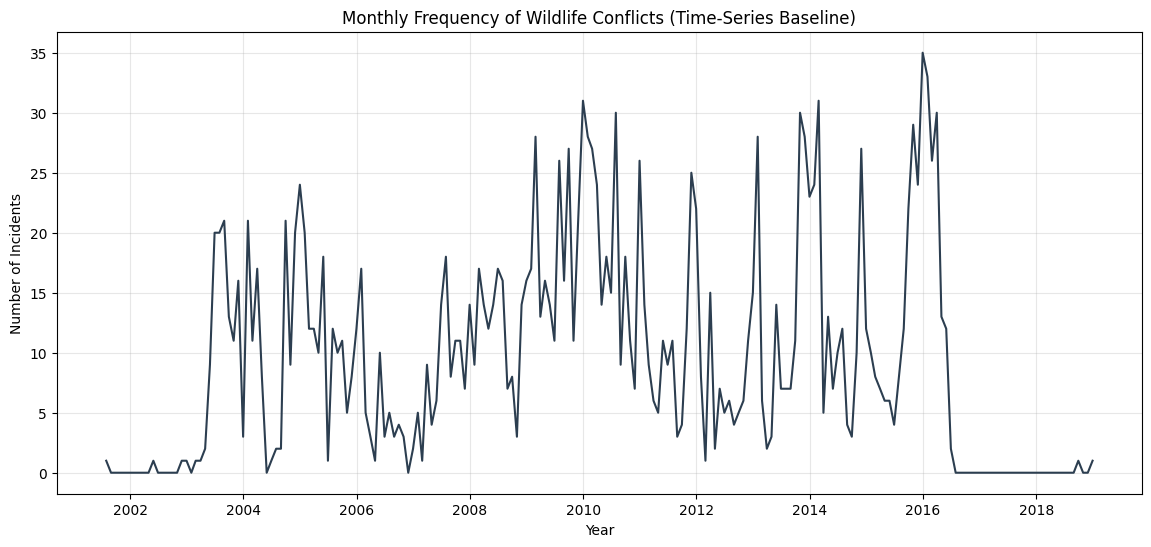

In [ ]:
# 1. Timeseries plot for frequency of Wildlife Conflicts

# Convert Year/Month/Day to a datetime object for plotting
df_timeseries['Date'] = pd.to_datetime(df_timeseries[['Year', 'Month', 'Day']])

# Resample to count incidents per month
monthly_counts = df_timeseries.set_index('Date').resample('M').size()

plt.figure(figsize=(14, 6))
plt.plot(monthly_counts, color='#2c3e50', linewidth=1.5)
plt.title('Monthly Frequency of Wildlife Conflicts (Time-Series Baseline)')
plt.xlabel('Year')
plt.ylabel('Number of Incidents')
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_1010/739955731.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_timeseries, x='Month', y=df_timeseries.groupby(['Year', 'Month']).transform('size'), palette='Spectral')


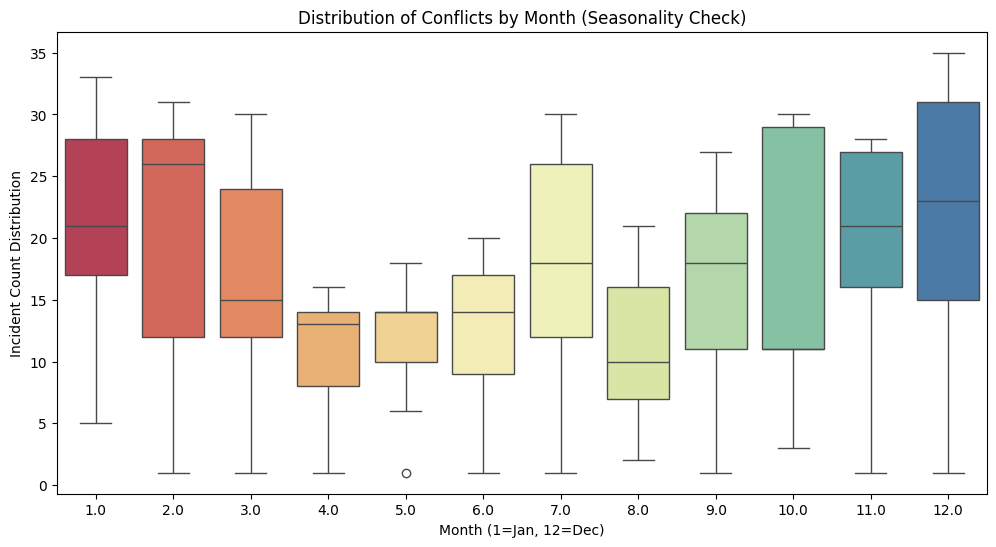

In [ ]:
# 2. Boxplot for Distribution of conflicts by month

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_timeseries, x='Month', y=df_timeseries.groupby(['Year', 'Month']).transform('size'), palette='Spectral')
plt.title('Distribution of Conflicts by Month (Seasonality Check)')
plt.ylabel('Incident Count Distribution')
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.show()

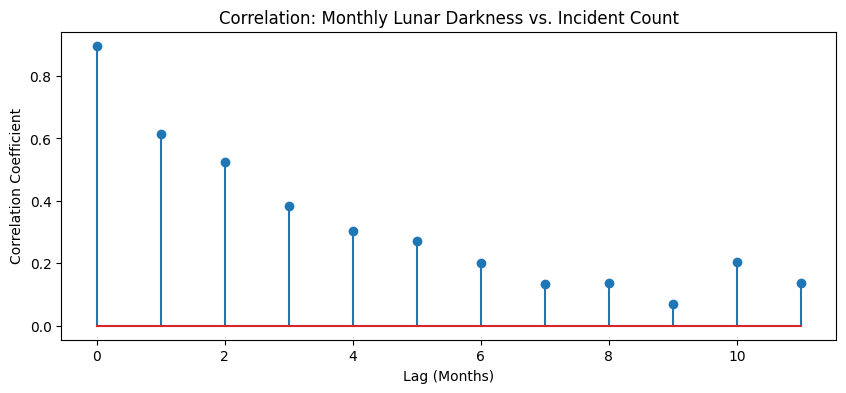

In [ ]:
# 3. Cross-Correlation Plot: Does the Moon lead the attacks?
def plot_cross_correlation(x, y, lags=12):
    corr = [x.corr(y.shift(i)) for i in range(lags)]
    plt.figure(figsize=(10, 4))
    plt.stem(range(lags), corr)
    plt.title('Correlation: Monthly Lunar Darkness vs. Incident Count')
    plt.xlabel('Lag (Months)')
    plt.ylabel('Correlation Coefficient')
    plt.show()

plot_cross_correlation(monthly_df['incident_count'], monthly_df['dark_intensity'])

## ADF Test (Stationarity Check)

In [ ]:
# Statistical test for stationarity:
# p < 0.05 means the data's mean/variance are stable and ready for ARIMA modeling.

from statsmodels.tsa.stattools import adfuller

# 1. Prepare the monthly series
# Ensure 'Date' is set as index and we have a consistent monthly frequency
monthly_series = df_timeseries.set_index('Date').resample('M').size()

# 2. Run the Augmented Dickey-Fuller test
result = adfuller(monthly_series)

print('--- ADF Test Results ---')
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

if result[1] < 0.05:
    print("Result: Data is stationary. Proceed to ACF/PACF.")
else:
    print("Result: Data is non-stationary. You will likely need d=1 in ARIMA.")

--- ADF Test Results ---
ADF Statistic: -4.396883310534784
p-value: 0.00030062531166266286
Result: Data is stationary. Proceed to ACF/PACF.


/tmp/ipykernel_1010/2463425559.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_series = df_timeseries.set_index('Date').resample('M').size()


## ACF and PACF Plots (Finding $p$ and $q$)

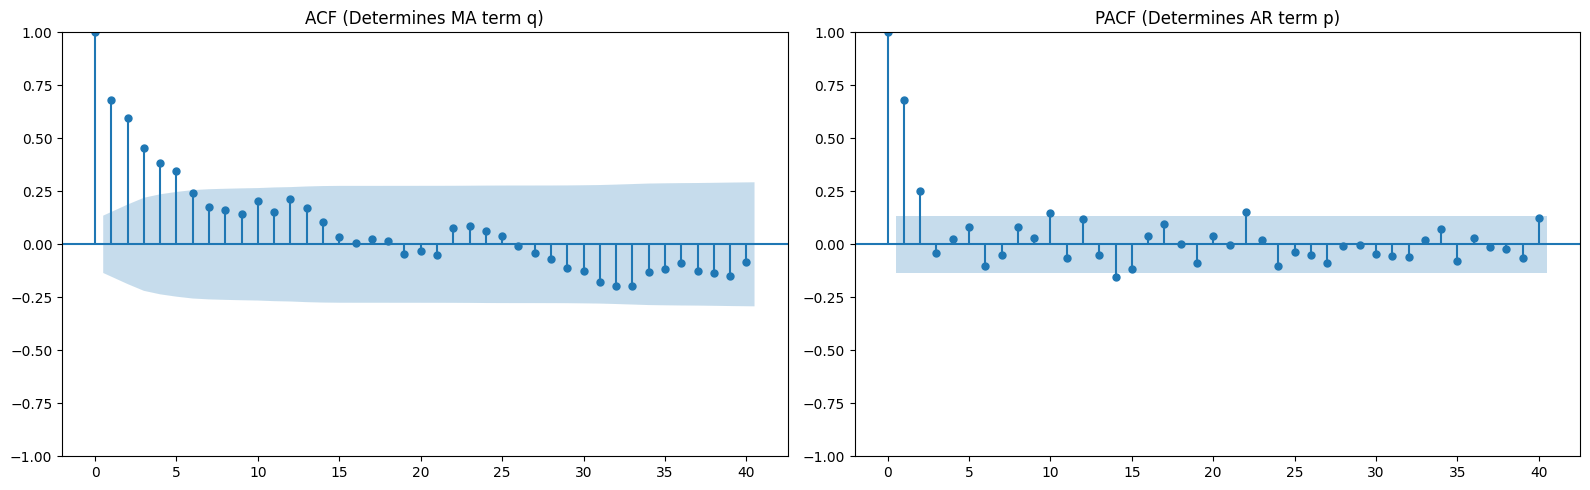

In [ ]:
# Autocorrelation Function (ACF):
# Used to identify the Moving Average (MA) term 'q' by showing how current values relate to past errors.

# Partial Autocorrelation Function (PACF):
# Used to identify the Auto-Regressive (AR) term 'p' by showing the direct relationship between a lag and the current value.

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Set up the plotting area
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot Autocorrelation (To find 'q')
plot_acf(monthly_series, lags=40, ax=ax1)
ax1.set_title('ACF (Determines MA term q)')

# Plot Partial Autocorrelation (To find 'p')
plot_pacf(monthly_series, lags=40, ax=ax2)
ax2.set_title('PACF (Determines AR term p)')

plt.tight_layout()
plt.show()

## ARIMA Model Training

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Define the series (Monthly incident counts)
# Using the monthly_series you generated for the ADF test
history = monthly_series.astype(float)

In [ ]:
# Fitting the ARIMA(2, 0, 2) model
# order=(p, d, q)
model = ARIMA(history, order=(2, 0, 2))
model_fit = model.fit()

In [ ]:
# Forecasting the next 12 months
forecast_steps = 12
forecast = model_fit.get_forecast(steps=forecast_steps)
forecast_idx = pd.date_range(start=history.index[-1] + pd.DateOffset(months=1),
                             periods=forecast_steps, freq='MS')
forecast_values = forecast.predicted_mean
conf_int = forecast.conf_int()

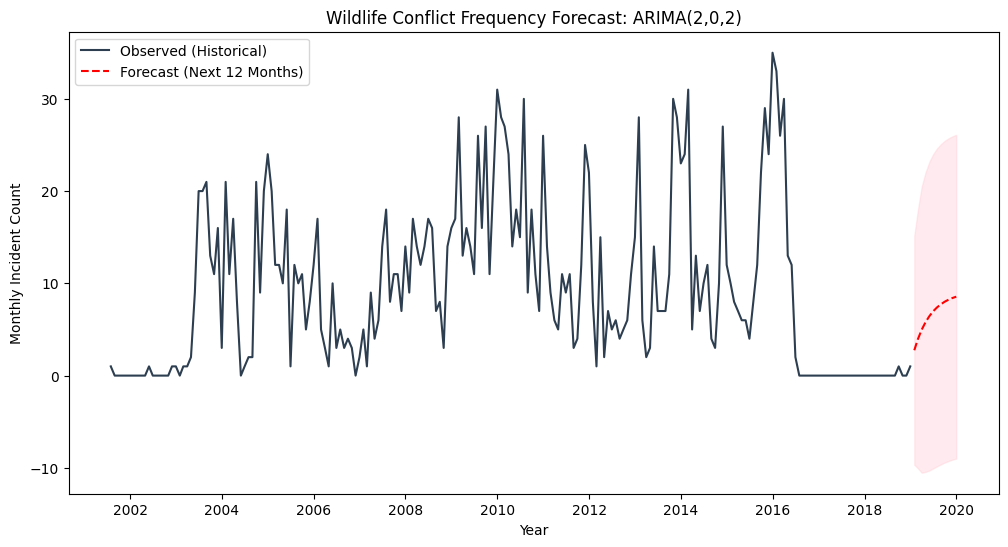

In [ ]:
# Plotting the results
plt.figure(figsize=(12, 6))
plt.plot(history, label='Observed (Historical)', color='#2c3e50')
plt.plot(forecast_idx, forecast_values, label='Forecast (Next 12 Months)', color='red', linestyle='--')
plt.fill_between(forecast_idx, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3)
plt.title('Wildlife Conflict Frequency Forecast: ARIMA(2,0,2)')
plt.xlabel('Year')
plt.ylabel('Monthly Incident Count')
plt.legend()
plt.show()

In [ ]:
# Model Summary
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  210
Model:                 ARIMA(2, 0, 2)   Log Likelihood                -685.836
Date:                Sat, 21 Mar 2026   AIC                           1383.673
Time:                        09:30:55   BIC                           1403.755
Sample:                    07-31-2001   HQIC                          1391.791
                         - 12-31-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.1428      2.553      3.582      0.000       4.139      14.146
ar.L1          0.3862      0.463      0.834      0.404      -0.522       1.294
ar.L2          0.3365      0.411      0.818      0.4

## SARIMA

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error

# DATA PREP (CUT OFF AT 2016)
# We exclude 2017 because the records are incomplete (under-reported)
df_clean = monthly_df[monthly_df.index.year <= 2016].copy()

# Split: Train on 2001-2015, Test on the high-conflict year 2016
train_data = df_clean[df_clean.index.year < 2016]
test_data = df_clean[df_clean.index.year == 2016]

# FIT BASELINE (SARIMA - No Moon)
sarima_base = SARIMAX(train_data['incident_count'],
                      order=(2, 0, 2),
                      seasonal_order=(1, 1, 1, 12)).fit(disp=False)
base_forecast = sarima_base.get_forecast(steps=12)
base_means = base_forecast.predicted_mean

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


## SARIMAX

In [ ]:
# FIT OPTIMIZED
# This model SEES the moon (dark_intensity)
sarimax_lunar = SARIMAX(train_data['incident_count'],
                        exog=train_data['dark_intensity'],
                        order=(2, 0, 2),
                        seasonal_order=(1, 1, 1, 12)).fit(disp=False)
lunar_forecast = sarimax_lunar.get_forecast(steps=12, exog=test_data['dark_intensity'])
lunar_means = lunar_forecast.predicted_mean

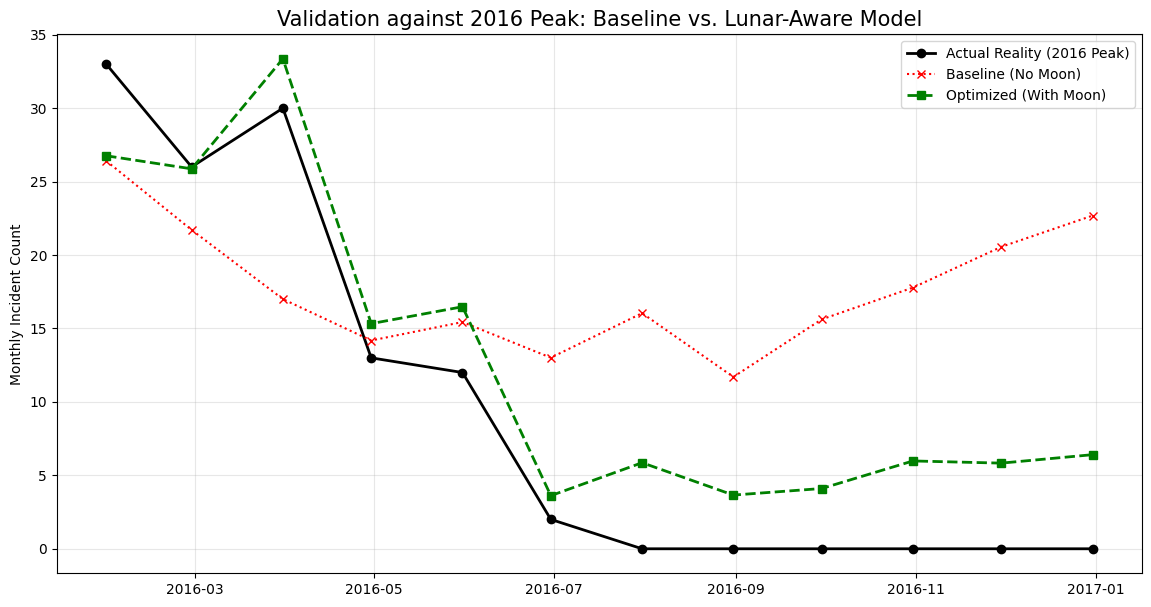

In [ ]:
# THE COMPARISON PLOT
plt.figure(figsize=(14, 7))
plt.plot(test_data.index, test_data['incident_count'], label='Actual Reality (2016 Peak)', color='black', marker='o', linewidth=2)
plt.plot(base_means.index, base_means, label='Baseline (No Moon)', color='red', linestyle=':', marker='x')
plt.plot(lunar_means.index, lunar_means, label='Optimized (With Moon)', color='green', linestyle='--', marker='s', linewidth=2)

plt.title('Validation against 2016 Peak: Baseline vs. Lunar-Aware Model', fontsize=15)
plt.ylabel('Monthly Incident Count')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# PERFORMANCE SPECS
rmse_base = np.sqrt(mean_squared_error(test_data['incident_count'], base_means))
rmse_lunar = np.sqrt(mean_squared_error(test_data['incident_count'], lunar_means))
print(f"Baseline SARIMA RMSE: {rmse_base:.2f}")
print(f"Lunar-Aware SARIMAX RMSE: {rmse_lunar:.2f}")
print(f"Error Reduction: {((rmse_base - rmse_lunar) / rmse_base)*100:.1f}%")

Baseline SARIMA RMSE: 13.71
Lunar-Aware SARIMAX RMSE: 4.60
Error Reduction: 66.5%


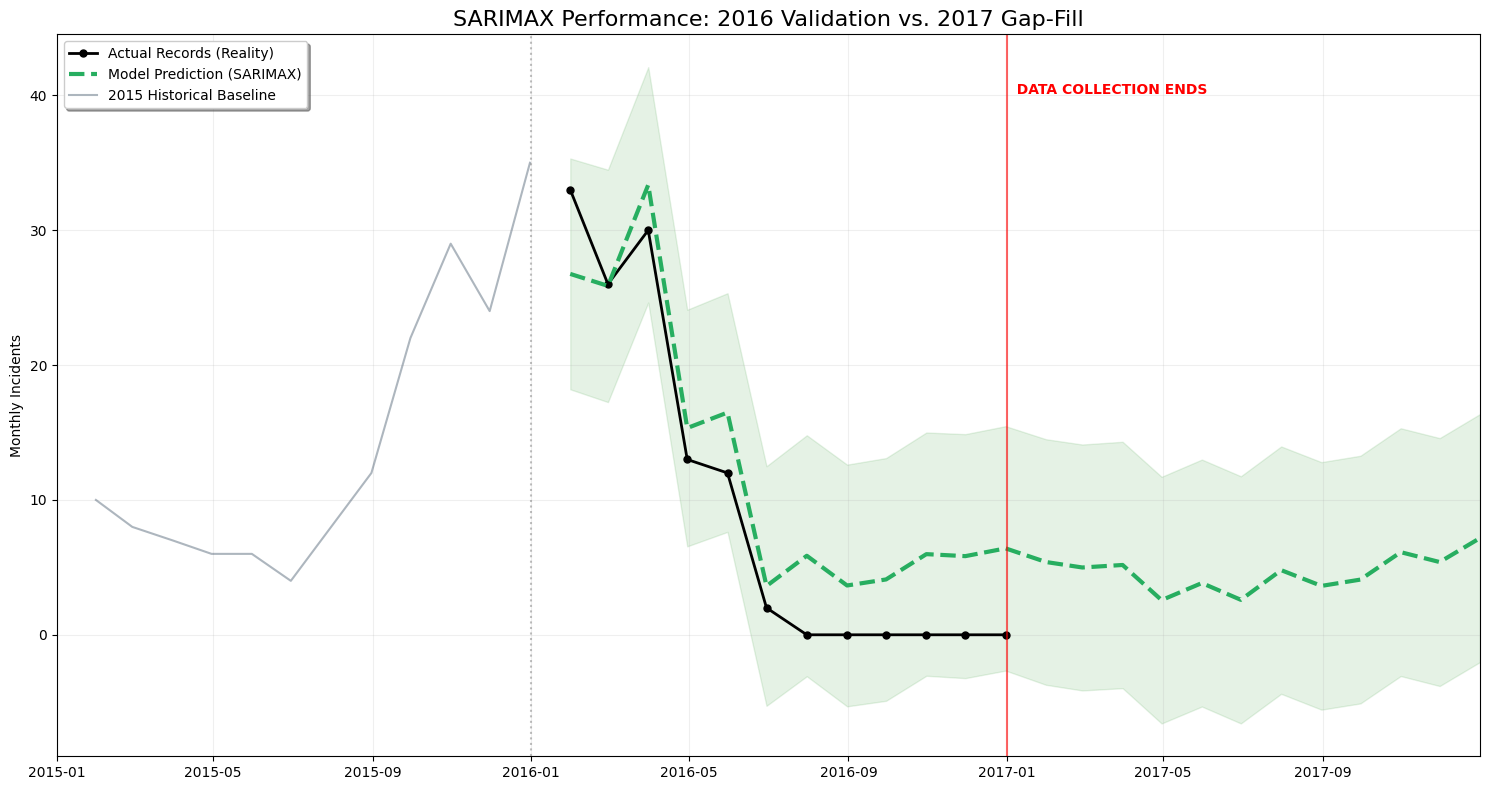

In [ ]:
# --- THE 24-MONTH CONTINUOUS FORECAST (2016-2017) ---

# 1. Combine the Lunar Data (Exog) for 2016 and 2017 into one sequence
# This allows the model to make one long 24-month prediction
exog_16_17 = monthly_df[(monthly_df.index.year >= 2016) & (monthly_df.index.year <= 2017)][['dark_intensity']]

# 2. Generate the 24-month forecast
# We use the model trained on data UP TO 2015 (sarimax_lunar)
full_forecast = sarimax_lunar.get_forecast(steps=24, exog=exog_16_17)
full_means = full_forecast.predicted_mean
full_conf = full_forecast.conf_int()

# 3. PLOTTING
plt.figure(figsize=(15, 8))

# A. Actual 2016 Records (The Black Line)
# This ends at Dec 2016 because 2017 data is missing/incomplete
plt.plot(test_data.index, test_data['incident_count'],
         label='Actual Records (Reality)', color='black', marker='o', markersize=5, linewidth=2)

# B. The Continuous Prediction Line (2016 through 2017)
# We plot the first 12 months as "Validation" and the next 12 as "Gap-Fill"
plt.plot(full_means.index, full_means,
         label='Model Prediction (SARIMAX)', color='#27ae60', linestyle='--', linewidth=3)

# Add the uncertainty range (Confidence Interval)
plt.fill_between(full_means.index, full_conf.iloc[:, 0], full_conf.iloc[:, 1], color='green', alpha=0.1)

# C. Highlight 2015 for context (optional but helpful)
recent_hist = train_data[train_data.index.year == 2015]
plt.plot(recent_hist.index, recent_hist['incident_count'],
         label='2015 Historical Baseline', color='#34495e', alpha=0.4)

# --- FORMATTING ---
plt.title('SARIMAX Performance: 2016 Validation vs. 2017 Gap-Fill', fontsize=16)
plt.ylabel('Monthly Incidents')

# Focus the X-axis on the 3-year window
plt.xlim(pd.Timestamp('2015-01-01'), pd.Timestamp('2017-12-31'))

# Visual Dividers
plt.axvline(pd.Timestamp('2016-01-01'), color='gray', linestyle=':', alpha=0.5)
plt.axvline(pd.Timestamp('2017-01-01'), color='red', linestyle='-', alpha=0.6)
plt.text(pd.Timestamp('2017-01-01'), plt.ylim()[1]*0.9, '  DATA COLLECTION ENDS', color='red', fontweight='bold')

plt.legend(loc='upper left', frameon=True, shadow=True)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
import joblib

# Save the validated SARIMAX (Lunar) model
# This is the model that saw the 15-year history and understands the moon
model_save_path = '/content/drive/MyDrive/Capstone I Project Folder (Models and Findings)/sarimax_lunar_model.pkl'
joblib.dump(sarimax_lunar, model_save_path)

print(f" Model saved successfully.")

 Model saved successfully.


In [ ]:
# Create a DataFrame for the 2017 Forecast (Reconstruction)
df_forecast_2017 = pd.DataFrame({
    'date': full_means.index,
    'incident_count_predicted': full_means.values,
    'lower_ci': full_conf.iloc[:, 0].values,
    'upper_ci': full_conf.iloc[:, 1].values,
    'data_type': 'Forecast/Gap-Fill'
})

# Get the Actual Historical Data (2015-2016)
df_actual_recent = df_clean[df_clean.index >= '2015-01-01'].copy()
df_actual_recent = df_actual_recent.reset_index()
df_actual_recent.columns = ['date', 'incident_count_actual', 'dark_intensity']
df_actual_recent['data_type'] = 'Actual Recorded'

# Merge them into one final "Master Spreadsheet"
final_export = pd.concat([df_actual_recent, df_forecast_2017], axis=0)

# Save to CSV
csv_save_path = '/content/drive/MyDrive/Capstone I Project Folder (Models and Findings)/chitwan_final_results_2015_2017.csv'
final_export.to_csv(csv_save_path, index=False)

print(f" Final CSV saved successfully.")
print("This CSV contains both the Actuals and the 2017 Reconstruction.")

 Final CSV saved successfully.
This CSV contains both the Actuals and the 2017 Reconstruction.


In [ ]:
from google.colab import drive
import os
import joblib

# 1. Mount the drive (It will ask for permission if not already connected)
drive.mount('/content/drive')

# 2. Define the path exactly
save_dir = '/content/drive/MyDrive/Capstone I Project Folder (Models and Findings)/'
file_name = 'sarimax_lunar_model.pkl'
full_path = os.path.join(save_dir, file_name)

# 3. Create the directory if it doesn't exist (prevents Errno 2)
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    print(f"Created new directory: {save_dir}")

# 4. Save the model again to be 100% sure it's there
try:
    joblib.dump(sarimax_lunar, full_path)
    print(f"✅ Success! Model saved at: {full_path}")

    # 5. Immediately try to load it back to verify
    check_model = joblib.load(full_path)
    print("✅ Verification Passed: Model is readable and not corrupted.")
    print(f"Model Order: {check_model.model.order}")

except NameError:
    print("❌ Error: 'sarimax_lunar' variable not found in memory. Run the cell where you trained the model first!")
except Exception as e:
    print(f"❌ An unexpected error occurred: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Success! Model saved at: /content/drive/MyDrive/Capstone I Project Folder (Models and Findings)/sarimax_lunar_model.pkl
✅ Verification Passed: Model is readable and not corrupted.
Model Order: (2, 0, 2)
